<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter7/7_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 신경망 모델 훈련

In [1]:
#데이터 가져오기 및 전처리 및 검증 세트 나누기
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 손실과 정확도 곡선

In [2]:
#모델 만드는 함수 정의
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Input(shape=(28,28)))
  model.add(keras.layers.Flatten())
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

In [3]:
#함수 호출
model = model_fn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#모델 훈련 및 결과를 history 변수에 담기
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5, verbose=0) #verbose는 훈련 과정 출력 조절. 기본값은 1로 에포크마다 진행 막대와 함께 손실 등의 지표가 출력됨. 2로 바꾸면 진행 막대 뺴고 출력.0은 출력 안함

In [5]:
#훈련 측정값은 history 객체에 history 딕셔너리에 들어가있음
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


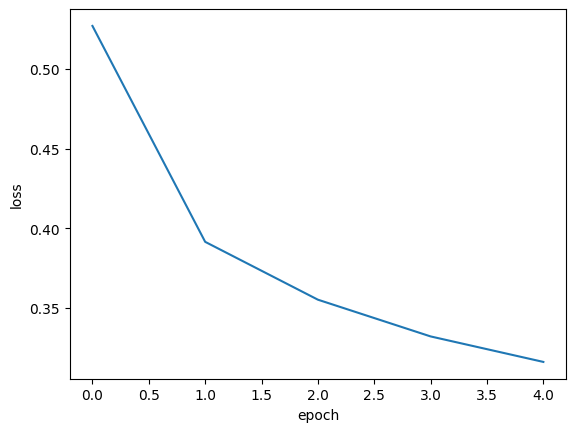

In [7]:
#손실 곡선과 정확도 곡선
import matplotlib.pyplot as plt

#손실
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

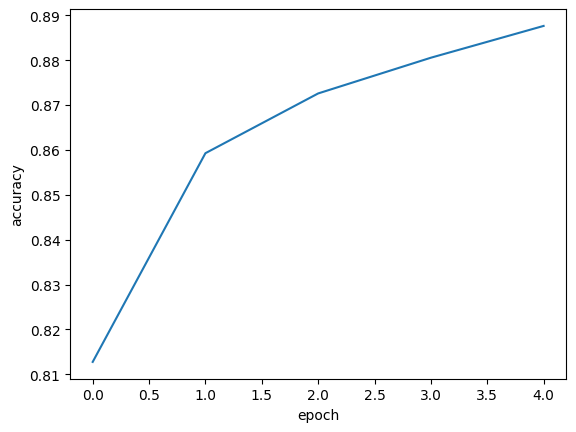

In [8]:
#정확도 곡선
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

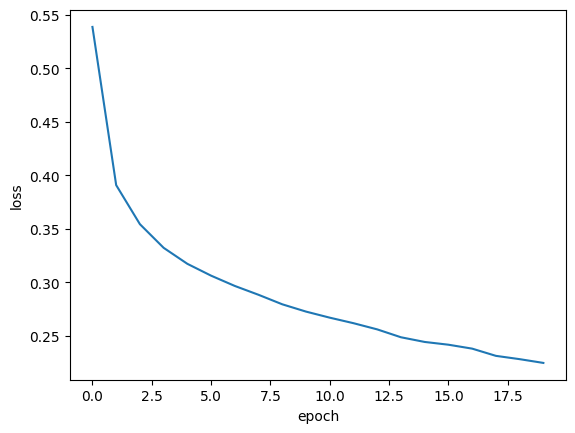

In [9]:
#에포크를 늘려서 훈련(손실 확인)
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 검증 손실

에포크에 따른 과소/과대 적합을 알아보기 위해서는 검증세트에 대한 점수도 필요함

In [13]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target)) #검증세트 추가

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


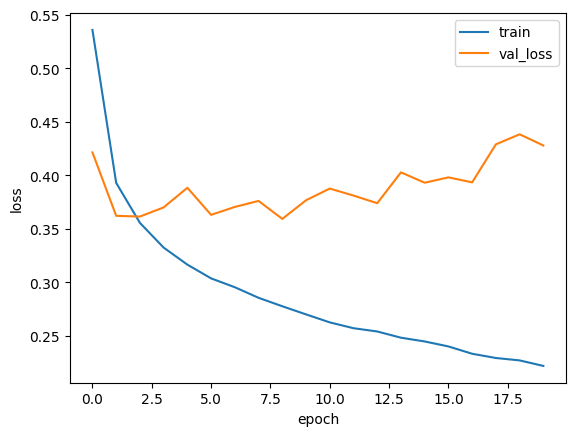

In [14]:
#곡선 그리기
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

#검증손실은 증가하고 훈련세트의 손실은 줄어드니 과대적합 문제가 나타난다. 이것을 해결하기 위한 규제방법도 존재.

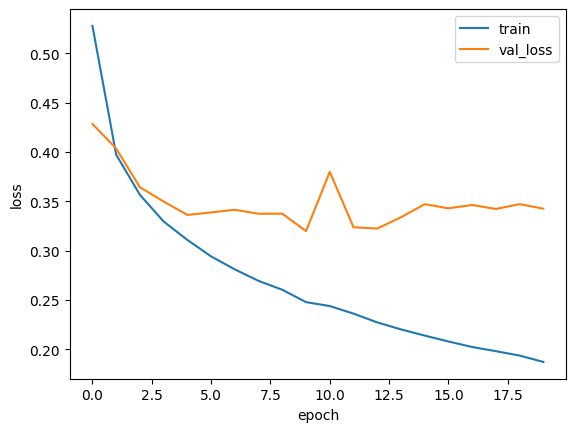

In [15]:
#규제 방법 사용전 옵티마이저 먼저 사용해보기
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

#곡선 그리기
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()
#옵티마이저 adam을 적용하니 과대적합이 많이 줄어들었다. 이는 adam이 이 데이터 셋에 잘맞는다는 것을 의미

## 드롭아웃

훈련과정에서 층에 있는 일부 뉴런을 랜덤하게 꺼서(즉 뉴런의 출력을 0으로 만들어) 과대적합을 막는다.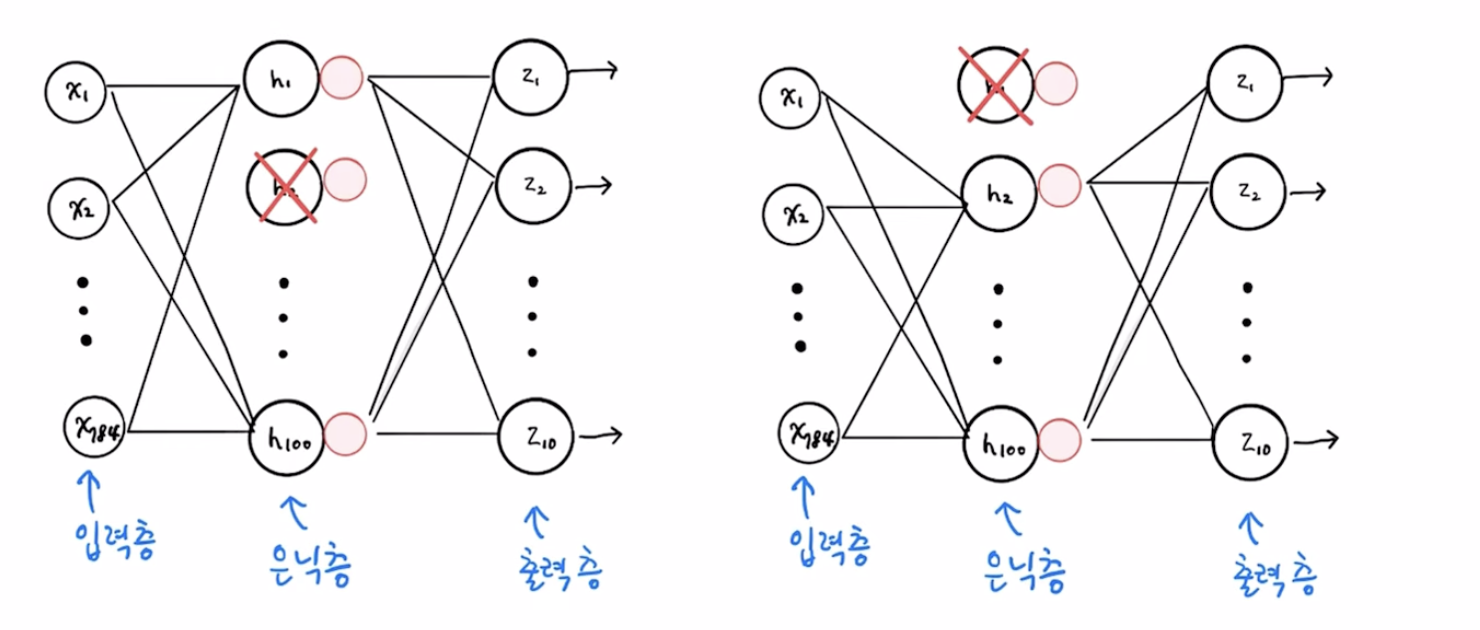

드롭아웃이 과대적합을 막는이유?

이전 층의 일부 뉴런이 랜덤하게 꺼지면 특정 뉴런에 과대하게 의존하는 것을 줄일 수 있고 모든 입력에 대해 주의를 기울여야 한다. 일부 뉴런의 출력이 없을 수 있다는 것을 감안하면 이 신경망은 더 안정적인 예측을 만들 수 있을 것이다.

혹은 2개의 신경망을 앙상블 하는것처럼 보일 수 있다. 앙상블은 과대적합을 막는 ㅇ좋은 기법이다.

In [16]:
#드롭아웃층 추가하기
model = model_fn(keras.layers.Dropout(0.3))  #30퍼의 뉴런 끄기
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

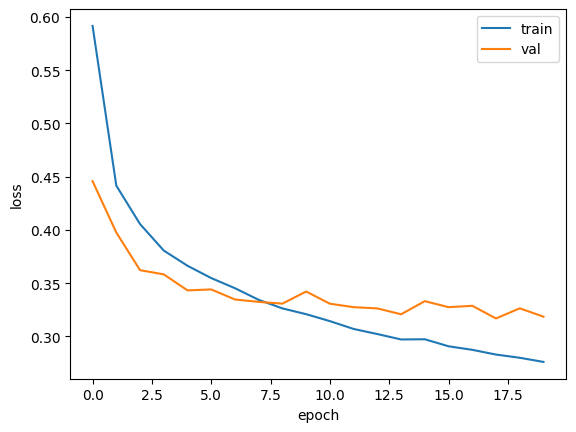

In [17]:
#평가나 예측을 수행할때는 드롭아웃을 적용하지 말아야함. 자동으로 빠짐
#곡선 그려보기
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()


## 모델 저장과 복원
에포크 횟수를 11(위 그래프에서 과대적합 되지않은 횟수)로 지정하고 모델 훈련.

또한 이 모델을 저장해야한다.

In [18]:
#에포크 11로 다시 훈련
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=11, verbose=0,
                    validation_data=(val_scaled, val_target))


In [24]:
#모델 저장(모델 구조와 파라미터를 모두 저장하여 압축)
model.save('model-whole.keras')


In [23]:
#가중치만 저장
model.save_weights('model.weights.h5')

In [25]:
#저장 확인
!ls -al model*

-rw-r--r-- 1 root root 976600 Apr  4 06:29 model.weights.h5
-rw-r--r-- 1 root root 979486 Apr  4 06:30 model-whole.keras


load 해보기

로드하기 위해서는 저장한 모델과 정확히 같은 구조를 만들어야한다.

In [26]:
#훈련하지 않은 새로운 모델을 만들고 훈련된 모델 파라미터 로드
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model.weights.h5')

토막 상식
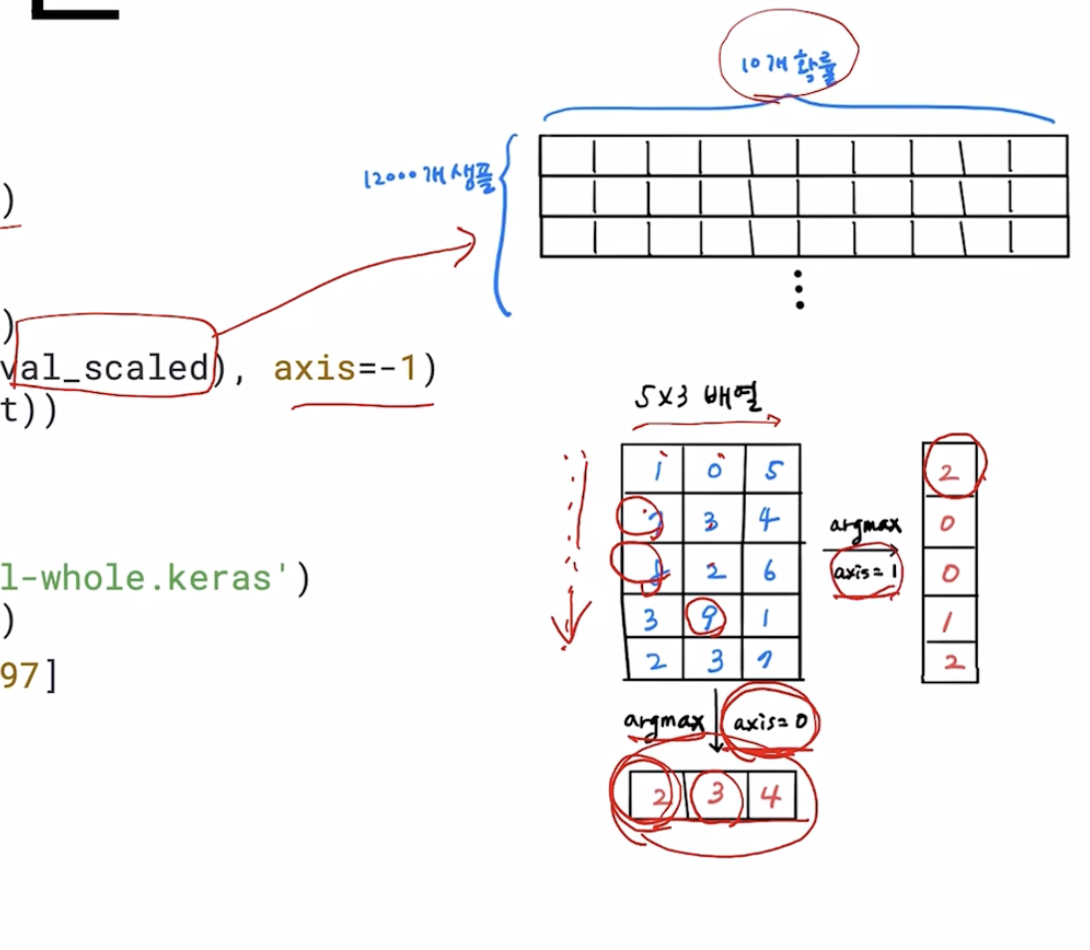

In [27]:
#검증 정확도 출력
import numpy as np

val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
0.8838333333333334


In [28]:
#모델 전체의 파일에서 읽은 다음 검증 세트 정확도 출력
model = keras.models.load_model('model-whole.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8838 - loss: 0.3229


[0.32289743423461914, 0.8838333487510681]

## 콜백
앞에서 20번 에포크 훈련하여 상승하는 지점 확인하고, 그 다음 모델을 과대적합 되지 않는 에포크만큼 다 훈련했었다.

모델을 두번 훈련하지 않고 한 번에 끝내는 방법이 콜백

In [29]:
#콜백 저장후 훈련할때 매개변수에 집어넣고 모델을 로드하기.
#모델 만들기
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#모델 체크포인트 객체 만들기
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)

#매개변수에 넣기
model.fit(train_scaled, train_target, epochs=20, verbose=0,
          validation_data=(val_scaled, val_target),
          callbacks= [checkpoint_cb])

In [30]:
#모델이 훈련한 후 berst-model.keras에 최상의 검증 점수를 낸 모델이 저장.
#가져오기
model = keras.models.load_model('best-model.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8878 - loss: 0.3165


[0.31649842858314514, 0.8878333568572998]

## 조기종료
검증세트의 손실이 커지게 되는 부분부터는 볼 필요가 없으니까 조기종료도 가능

In [32]:
#모델 만들기
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#모델 체크포인트 객체 만들기
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)

#조기종료 객체 만들기(patience는 2번 이후까지 점수가 안낮아지면 그만. restore_best_weights은 그전 가장 좋았던 곳까지 복원. 따라서 load_model할 필요가 없음)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

#훈련하기
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data = (val_scaled, val_target),
                    callbacks = [checkpoint_cb, early_stopping_cb])

print(early_stopping_cb.stopped_epoch)

9


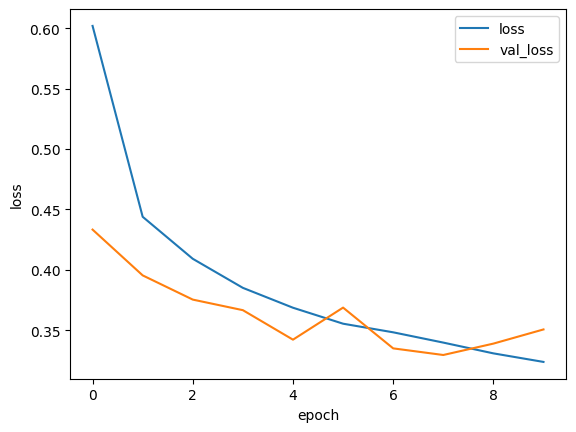

In [33]:
#곡선 그리기
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 최상의 신경망 모델 얻기
fit 메서드의 반환값을 사용해 훈련 세트와 검증 세트에 대한 손실을 그래프로 그려봄.

과대적합을 막히위해 대표적인 규제방법인 드롭아웃을 알아봄. 드롭아웃은 뉴런을 꺼서 앙상블 하는 효과를 냄.

저장과 복원도 알아봄. 또한 과대적합 되기 전의 에포크를 수동으로 찾아 모델을 훈ㄴ련하는 대신 콜백을 사용하면 자동을 최상의 모델을 유지하는 방법을 알아봄.